# Airbnb Price Analysis

## Objective
The goal of this project is to analyze Airbnb listing prices and identify patterns related to price distribution, neighbourhood, room type, and availability.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/archive/listings.csv")

## Data Exploration
The dataset was loaded and inspected to understand its structure, variables, and overall size.

In [3]:
display(df.head())
print("Shape:", df.shape)
display(pd.DataFrame(df.columns, columns=["Columns"]))
df.info()
display(df.describe())

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.45724,-3.67688,Private room,60,1,78,2020-09-20,0.58,1,180
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,31,4,33,2018-07-15,0.42,2,364
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.38840,-3.69511,Entire home/apt,50,15,0,NaN,NaN,7,1
3,24805,Gran Via Studio Madrid,346366726,A,Centro,Universidad,40.42183,-3.70529,Entire home/apt,92,5,10,2020-03-01,0.13,1,72
4,26825,Single Room whith private Bathroom,114340,Agustina,Arganzuela,Legazpi,40.38975,-3.69018,Private room,26,2,149,2020-03-12,1.12,1,365


Shape: (19618, 16)


,Columns
0,id
1,name
2,host_id
3,host_name
4,neighbourhood_group
5,neighbourhood
6,latitude
7,longitude
8,room_type
9,price


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19618 entries, 0 to 19617
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              19618 non-null  int64  
 1   name                            19615 non-null  object 
 2   host_id                         19618 non-null  int64  
 3   host_name                       19091 non-null  object 
 4   neighbourhood_group             19618 non-null  object 
 5   neighbourhood                   19618 non-null  object 
 6   latitude                        19618 non-null  float64
 7   longitude                       19618 non-null  float64
 8   room_type                       19618 non-null  object 
 9   price                           19618 non-null  int64  
 10  minimum_nights                  19618 non-null  int64  
 11  number_of_reviews               19618 non-null  int64  
 12  last_review                     

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,1.961800e+04,1.961800e+04,19618.000000,19618.000000,19618.000000,19618.000000,19618.000000,13981.000000,19618.000000,19618.000000
mean,2.912200e+07,1.312165e+08,40.420984,-3.694040,129.271740,6.586196,31.858803,1.125958,10.229177,159.098328
std,1.351839e+07,1.166790e+08,0.022627,0.028671,484.143545,33.286582,63.938997,1.348235,23.546472,144.252803
min,6.369000e+03,7.952000e+03,40.332210,-3.863910,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,1.903424e+07,2.765313e+07,40.409393,-3.707700,35.000000,1.000000,0.000000,0.170000,1.000000,0.000000
50%,3.187506e+07,9.901898e+07,40.419735,-3.701120,58.000000,2.000000,4.000000,0.590000,2.000000,126.000000
75%,4.090994e+07,2.256898e+08,40.430290,-3.685420,100.000000,3.000000,31.000000,1.630000,6.000000,320.000000
max,4.918779e+07,3.964281e+08,40.562740,-3.531900,9999.000000,1125.000000,706.000000,16.220000,163.000000,365.000000


## Initial Data Issues

Before cleaning, the dataset contains unrealistic values such as zero prices and extreme outliers. These values can distort summary statistics and need to be handled.

Initial max price: 9999
Initial mean price: 129.27174023855642
Initial median price: 58.0


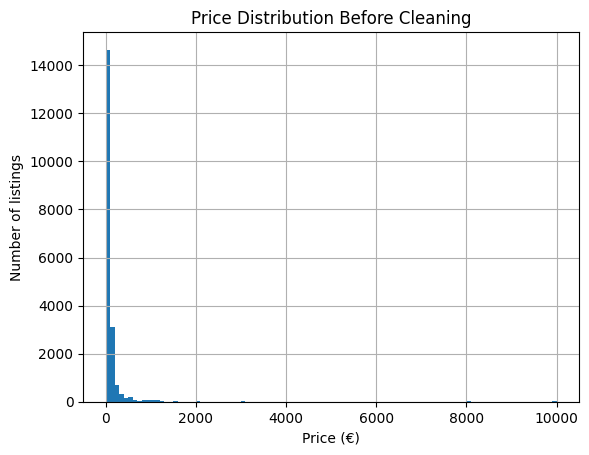

In [4]:
print("Initial max price:", df["price"].max())
print("Initial mean price:", df["price"].mean())
print("Initial median price:", df["price"].median())

df["price"].hist(bins=100)
plt.title("Price Distribution Before Cleaning")
plt.xlabel("Price (€)")
plt.ylabel("Number of listings")
plt.show()

## Data Cleaning
The initial price distribution included unrealistic values such as 0 and extremely high prices, which distorted the analysis.

Listings with price equal to 0 were removed, and prices above the 99th percentile were excluded to reduce the impact of extreme outliers while preserving most of the dataset.

In [5]:
print("Rows before cleaning:", len(df))
df = df[df["price"] > 0]
upper_limit = df["price"].quantile(0.99)
df = df[df["price"] < upper_limit]    
print("Rows after cleaning:", len(df))
print("Max price after cleaning:", df["price"].max())

Rows before cleaning: 19618
Rows after cleaning: 19402
Max price after cleaning: 1114


## Price Analysis
Price distribution was analyzed using mean, median, percentiles, and a histogram to understand the typical price range and the overall shape of Airbnb prices.

Mean price (€):  93.68
Median price (€):  58.0

Price distribution percentiles (€):


0.25     35.0
0.50     58.0
0.75     99.0
0.90    178.0
Name: price, dtype: float64

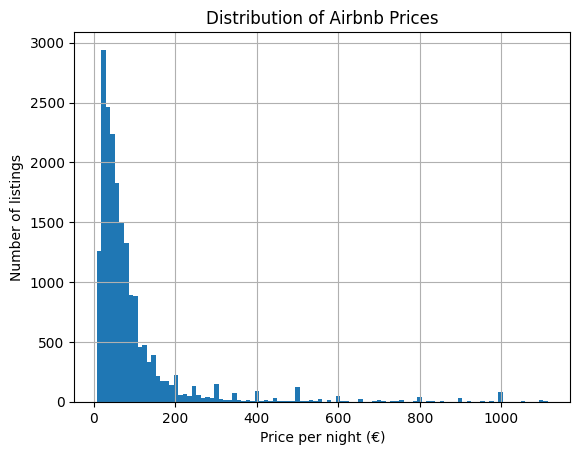

In [6]:
print("Mean price (€): ", round(df["price"].mean(), 2))
print("Median price (€): ", round(df["price"].median(), 2))
print("\nPrice distribution percentiles (€):")
display(df["price"].quantile([0.25, 0.5, 0.75, 0.9]).round(2))

df["price"].hist(bins=100)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per night (€)")
plt.ylabel("Number of listings")
plt.show()

Most listings are concentrated in lower price ranges, while a smaller number of expensive listings creates a right-skewed distribution.

## Neighbourhood Analysis
Average prices were compared across neighbourhoods to identify which areas tend to be more expensive.

neighbourhood
Hellín              434.17
Rosas               327.88
Canillejas          241.00
Arcos               214.56
Amposta             209.88
El Pardo            195.00
Simancas            192.67
Marroquina          177.12
El Goloso           158.67
Alameda de Osuna    158.12
Name: price, dtype: float64

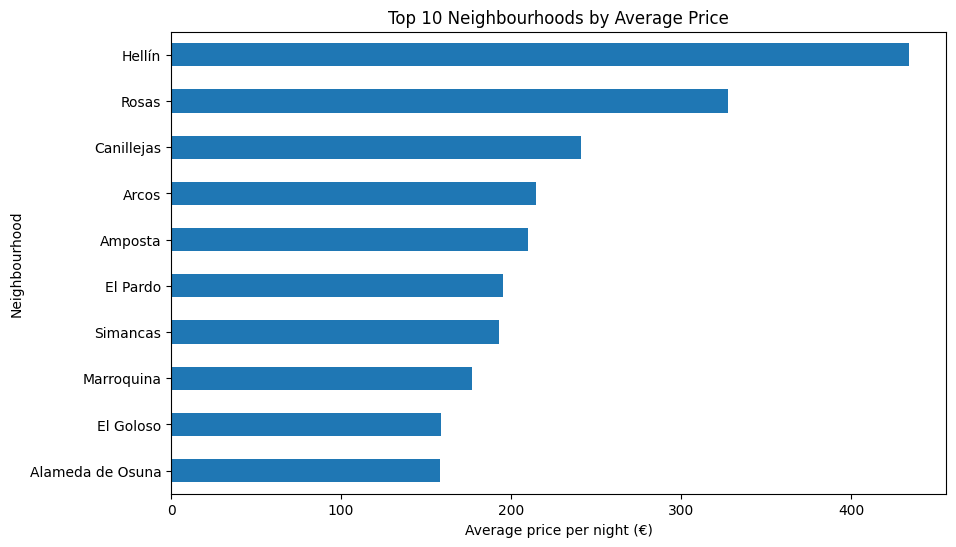

In [7]:
neighbourhood_prices = df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False).head(10)

display(neighbourhood_prices.round(2))

neighbourhood_prices.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Neighbourhoods by Average Price")
plt.xlabel("Average price per night (€)")
plt.ylabel("Neighbourhood")
plt.show()

The most expensive neighbourhoods show noticeably higher average prices, suggesting that location is one of the strongest pricing factors.

## Room Type Analysis
Prices and listing counts were compared across room types to understand how accommodation type affects pricing.

,Avg price (€),Median price (€),Listings
room_type,,,
Hotel room,152.49,87.5,154
Entire home/apt,110.95,77.0,11156
Private room,68.90,32.0,7766
Shared room,65.31,21.0,326


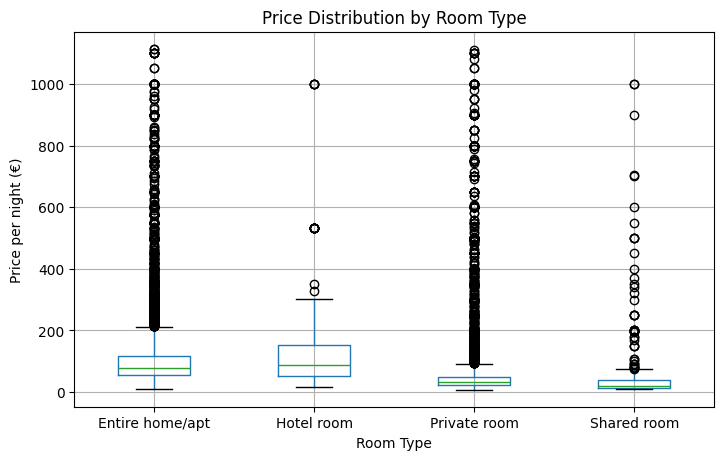

In [8]:
room_summary = pd.DataFrame({"Avg price (€)": df.groupby("room_type")["price"].mean(), "Median price (€)": df.groupby("room_type")["price"].median(), "Listings": df["room_type"].value_counts()})

display(room_summary.sort_values(by="Avg price (€)", ascending=False).round(2))

df.boxplot(column="price", by="room_type", figsize=(8, 5))
plt.title("Price Distribution by Room Type")
plt.suptitle("")
plt.xlabel("Room Type")
plt.ylabel("Price per night (€)")
plt.show()

The difference between mean and median prices indicates that some room types are affected by high-priced listings.

For example, when the mean is higher than the median, it suggests the presence of expensive outliers increasing the average price. This effect is more visible in entire homes and hotel rooms.

## Price and Availability
The relationship between price and availability was analyzed to check whether more expensive listings tend to be available for more or fewer days during the year.

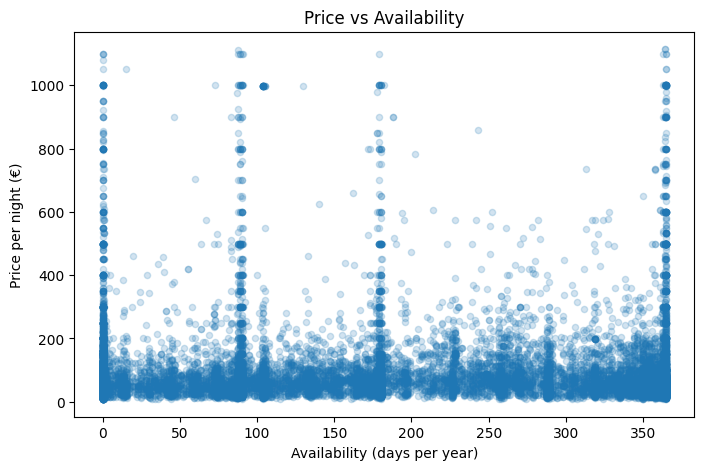

In [9]:
df.plot.scatter(x="availability_365", y="price", alpha=0.2, figsize=(8, 5))

plt.title("Price vs Availability")
plt.xlabel("Availability (days per year)")
plt.ylabel("Price per night (€)")
plt.show()

There is no clear linear relationship between price and availability, suggesting that availability alone is not a strong predictor of price.

## Conclusions
- The price distribution is highly right-skewed, meaning that most listings are relatively affordable, while a small number of high-priced listings increase the average.
- Removing extreme outliers made the analysis more representative of typical Airbnb listings.
- Location appears to play an important role in pricing, as some neighbourhoods show noticeably higher average prices.
- Entire homes dominate the market and are generally priced higher, indicating stronger demand for full-property rentals.
- Private and shared rooms tend to compete on lower prices, suggesting a more budget-oriented segment.
- No strong relationship was observed between price and availability, indicating that pricing is likely influenced more by property characteristics and location than by availability alone.